In [ ]:
!rm -rf /content/drive
!mkdir /content/drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Network ', 'Colab Notebooks', 'Dataset', 'DR_New_Results', 'APTOS']


In [3]:
# checkpoint_path defined here; actual load runs after model init
checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"
start_epoch = 0
# Actual loading happens in the post-model cell below

 **Import Libraries**


In [4]:
!pip install timm imbalanced-learn
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import matplotlib.cm as cm
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

In [5]:
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
COLAB_RESULTS_PATH = "/content/DR_New_Results/APTOS"

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
os.makedirs(COLAB_RESULTS_PATH, exist_ok=True)

print("Drive Path:", DRIVE_RESULTS_PATH)
print("Colab Path:", COLAB_RESULTS_PATH)

Drive Path: /content/drive/MyDrive/DR_New_Results/APTOS
Colab Path: /content/DR_New_Results/APTOS


 **Reproducibility — Set Random Seed**

**OVERSAMPLING PIPELINE CODE**

In [6]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**APTOS Dataset Preprocessing**




In [7]:
import os
import pandas as pd

aptos_root = "/content/drive/MyDrive/Dataset/Full APTOS/2019"
csv_path = os.path.join(aptos_root, "train.csv")

# load csv
aptos_df = pd.read_csv(csv_path)

# rename label
aptos_df.rename(columns={"diagnosis": "label"}, inplace=True)

# create image paths
image_dict = {}
for root, _, files in os.walk(aptos_root):
    for file in files:
        if file.endswith(".png"):
            img_id = os.path.splitext(file)[0]
            image_dict[img_id] = os.path.join(root, file)

aptos_df["image_path"] = aptos_df["id_code"].map(image_dict)

# remove missing images
aptos_df = aptos_df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Dataset loaded:", len(aptos_df))

Dataset loaded: 3662


**APTOS Dataset Balancing Visualization**

===== FULL DATASET BEFORE =====
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

===== FULL DATASET AFTER =====
label
0    1805
1    1805
2    1805
3    1805
4    1805
Name: count, dtype: int64


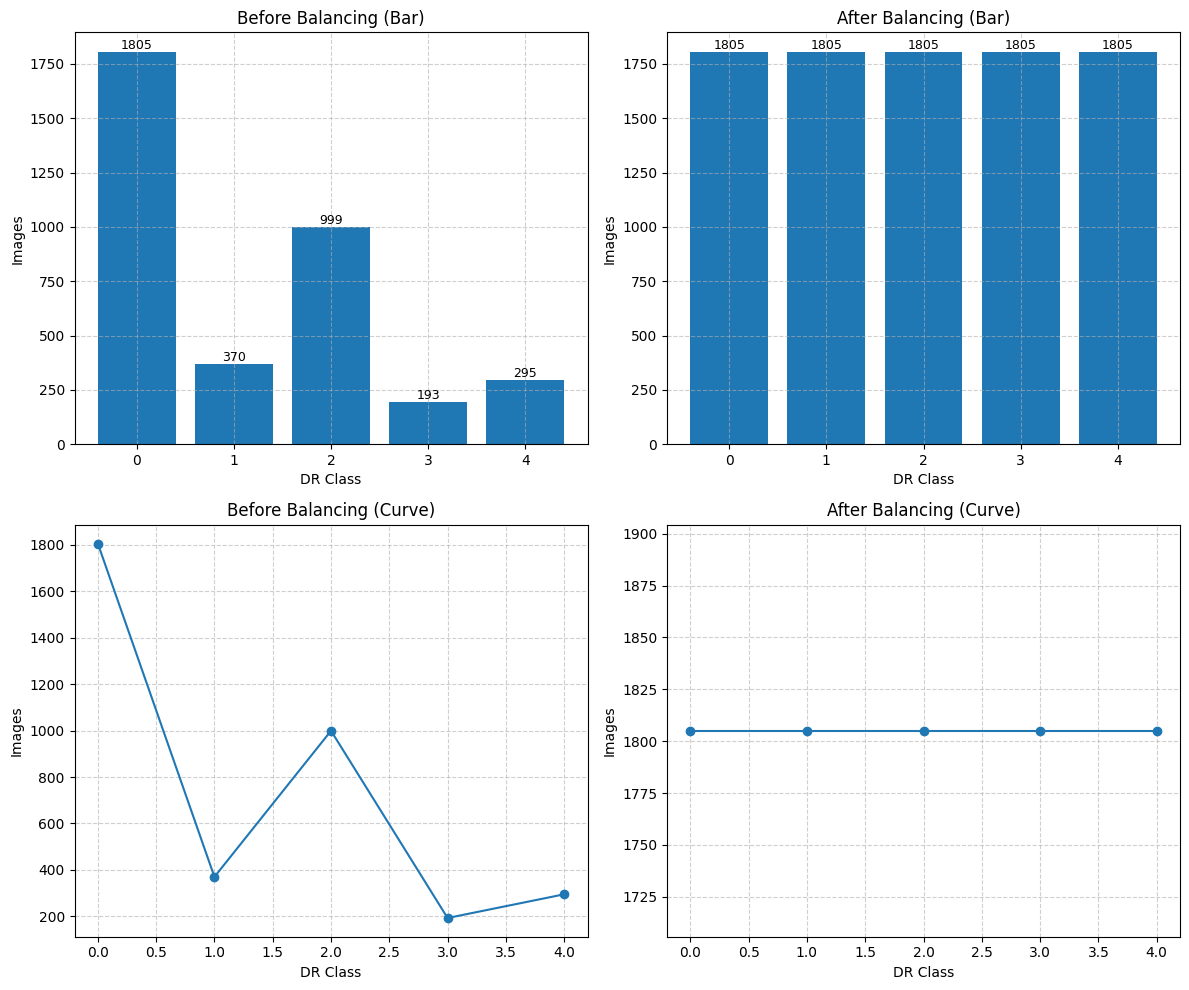


Row-wise visualization saved at: /content/drive/MyDrive/DR_New_Results/APTOS/final_distribution_rowwise.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# FUNCTION: ADD LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# =========================
# BEFORE BALANCING
# =========================
before_counts = aptos_df[
    "label"
].value_counts().sort_index()

print("===== FULL DATASET BEFORE =====")

print(before_counts)

# =========================
# TEMP BALANCING
# =========================
max_count = before_counts.max()

balanced_temp = []

for cls in before_counts.index:

    cls_df = aptos_df[
        aptos_df["label"] == cls
    ]

    sampled = cls_df.sample(
        n=max_count,
        replace=True,
        random_state=42
    )

    balanced_temp.append(sampled)

df_balanced_temp = pd.concat(
    balanced_temp
).reset_index(drop=True)

# =========================
# AFTER BALANCING
# =========================
after_counts = df_balanced_temp[
    "label"
].value_counts().sort_index()

print("\n===== FULL DATASET AFTER =====")

print(after_counts)

# =========================
# COMMON STYLE FUNCTION
# =========================
def style_plot(ax, title):

    ax.set_title(title)

    ax.set_xlabel("DR Class")

    ax.set_ylabel("Images")

    ax.grid(
        True,
        linestyle='--',
        alpha=0.6
    )

# =========================
# PLOTS
# =========================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

# BEFORE BAR
axes[0,0].bar(
    before_counts.index,
    before_counts.values
)

add_labels(axes[0,0])

style_plot(
    axes[0,0],
    "Before Balancing (Bar)"
)

# AFTER BAR
axes[0,1].bar(
    after_counts.index,
    after_counts.values
)

add_labels(axes[0,1])

style_plot(
    axes[0,1],
    "After Balancing (Bar)"
)

# BEFORE CURVE
axes[1,0].plot(
    before_counts.index,
    before_counts.values,
    marker='o'
)

style_plot(
    axes[1,0],
    "Before Balancing (Curve)"
)

# AFTER CURVE
axes[1,1].plot(
    after_counts.index,
    after_counts.values,
    marker='o'
)

style_plot(
    axes[1,1],
    "After Balancing (Curve)"
)

plt.tight_layout()

# =========================
# SAVE
# =========================
save_path = "/content/drive/MyDrive/DR_New_Results/APTOS/final_distribution_rowwise.png"

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# DONE
# =========================
print(
    f"\nRow-wise visualization saved at: {save_path}"
)

**Dataset Class Distribution Before and After Balancing**

===== ORIGINAL DATASET =====
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

===== OVERLAP CHECK =====
Train-Val: 0
Train-Test: 0
Val-Test: 0

===== TRAIN DISTRIBUTION =====
label
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64


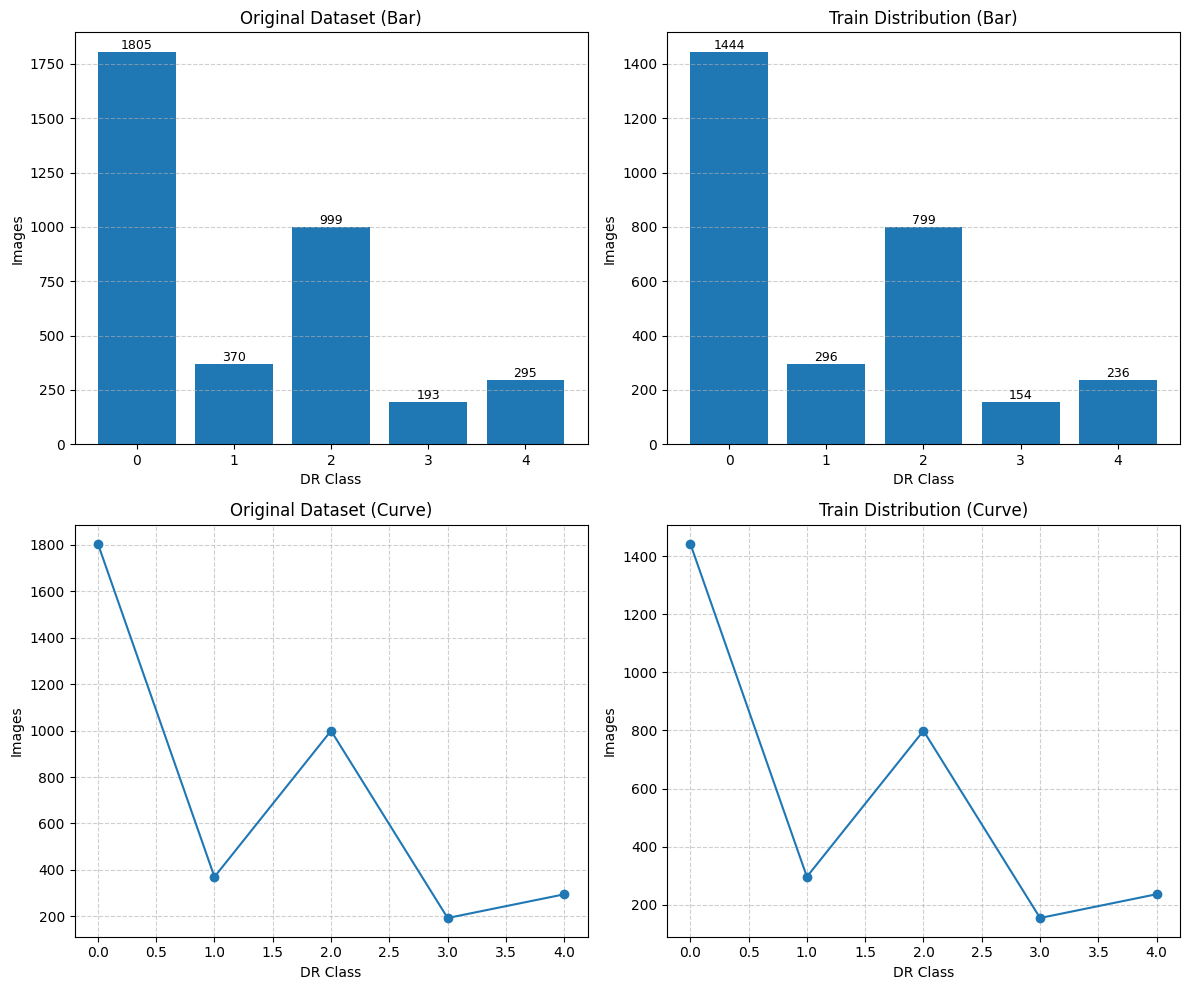


 Visualization saved at:
/content/drive/MyDrive/DR_New_Results/APTOS/train_distribution_rowwise.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =========================
# SAVE PATH
# =========================
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    DRIVE_RESULTS_PATH,
    exist_ok=True
)

# =========================
# FUNCTION: ADD LABELS
# =========================
def add_labels(ax):

    for p in ax.patches:

        height = p.get_height()

        ax.annotate(
            f'{int(height)}',

            (
                p.get_x() + p.get_width()/2,
                height
            ),

            ha='center',

            va='bottom',

            fontsize=9
        )

# =========================
# STEP 1 — ORIGINAL DATASET
# =========================
before_counts = aptos_df[
    "label"
].value_counts().sort_index()

print("===== ORIGINAL DATASET =====")

print(before_counts)

# =========================
# STEP 2 — SPLIT
# =========================
train_df, temp_df = train_test_split(

    aptos_df,

    test_size=0.2,

    stratify=aptos_df["label"],

    random_state=42
)

val_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=42
)

# =========================
# STEP 3 — OVERLAP CHECK
# =========================
train_set = set(
    train_df["image_path"]
)

val_set = set(
    val_df["image_path"]
)

test_set = set(
    test_df["image_path"]
)

print("\n===== OVERLAP CHECK =====")

print(
    "Train-Val:",
    len(train_set & val_set)
)

print(
    "Train-Test:",
    len(train_set & test_set)
)

print(
    "Val-Test:",
    len(val_set & test_set)
)

# =========================
# STEP 4 — TRAIN DISTRIBUTION
# =========================
after_counts = train_df[
    "label"
].value_counts().sort_index()

print("\n===== TRAIN DISTRIBUTION =====")

print(after_counts)

# =========================
# PLOTS
# =========================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

# =========================
# BEFORE BAR
# =========================
axes[0,0].bar(

    before_counts.index,

    before_counts.values
)

add_labels(
    axes[0,0]
)

axes[0,0].set_title(
    "Original Dataset (Bar)"
)

axes[0,0].set_xlabel(
    "DR Class"
)

axes[0,0].set_ylabel(
    "Images"
)

axes[0,0].grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

# =========================
# TRAIN BAR
# =========================
axes[0,1].bar(

    after_counts.index,

    after_counts.values
)

add_labels(
    axes[0,1]
)

axes[0,1].set_title(
    "Train Distribution (Bar)"
)

axes[0,1].set_xlabel(
    "DR Class"
)

axes[0,1].set_ylabel(
    "Images"
)

axes[0,1].grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

# =========================
# BEFORE CURVE
# =========================
axes[1,0].plot(

    before_counts.index,

    before_counts.values,

    marker='o'
)

axes[1,0].set_title(
    "Original Dataset (Curve)"
)

axes[1,0].set_xlabel(
    "DR Class"
)

axes[1,0].set_ylabel(
    "Images"
)

axes[1,0].grid(
    True,
    linestyle='--',
    alpha=0.6
)

# =========================
# TRAIN CURVE
# =========================
axes[1,1].plot(

    after_counts.index,

    after_counts.values,

    marker='o'
)

axes[1,1].set_title(
    "Train Distribution (Curve)"
)

axes[1,1].set_xlabel(
    "DR Class"
)

axes[1,1].set_ylabel(
    "Images"
)

axes[1,1].grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

# =========================
# SAVE FIGURE
# =========================
save_path = os.path.join(

    DRIVE_RESULTS_PATH,

    "train_distribution_rowwise.png"
)

plt.savefig(
    save_path,
    dpi=300
)

plt.show()

# =========================
# FINAL MESSAGE
# =========================
print(
    f"\n Visualization saved at:\n{save_path}"
)

**Dataset Splitting and Balancing**

===== BEFORE BALANCING =====

Train (Original):
 label
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Validation:
 label
0    180
1     37
2    100
3     20
4     29
Name: count, dtype: int64

Test:
 label
0    181
1     37
2    100
3     19
4     30
Name: count, dtype: int64

===== AFTER BALANCING =====

Train (Balanced):
 label
0    1444
1    1444
2    1444
3    1444
4    1444
Name: count, dtype: int64


/tmp/ipykernel_1323/2676140221.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_train_df = train_df.groupby("label").apply(


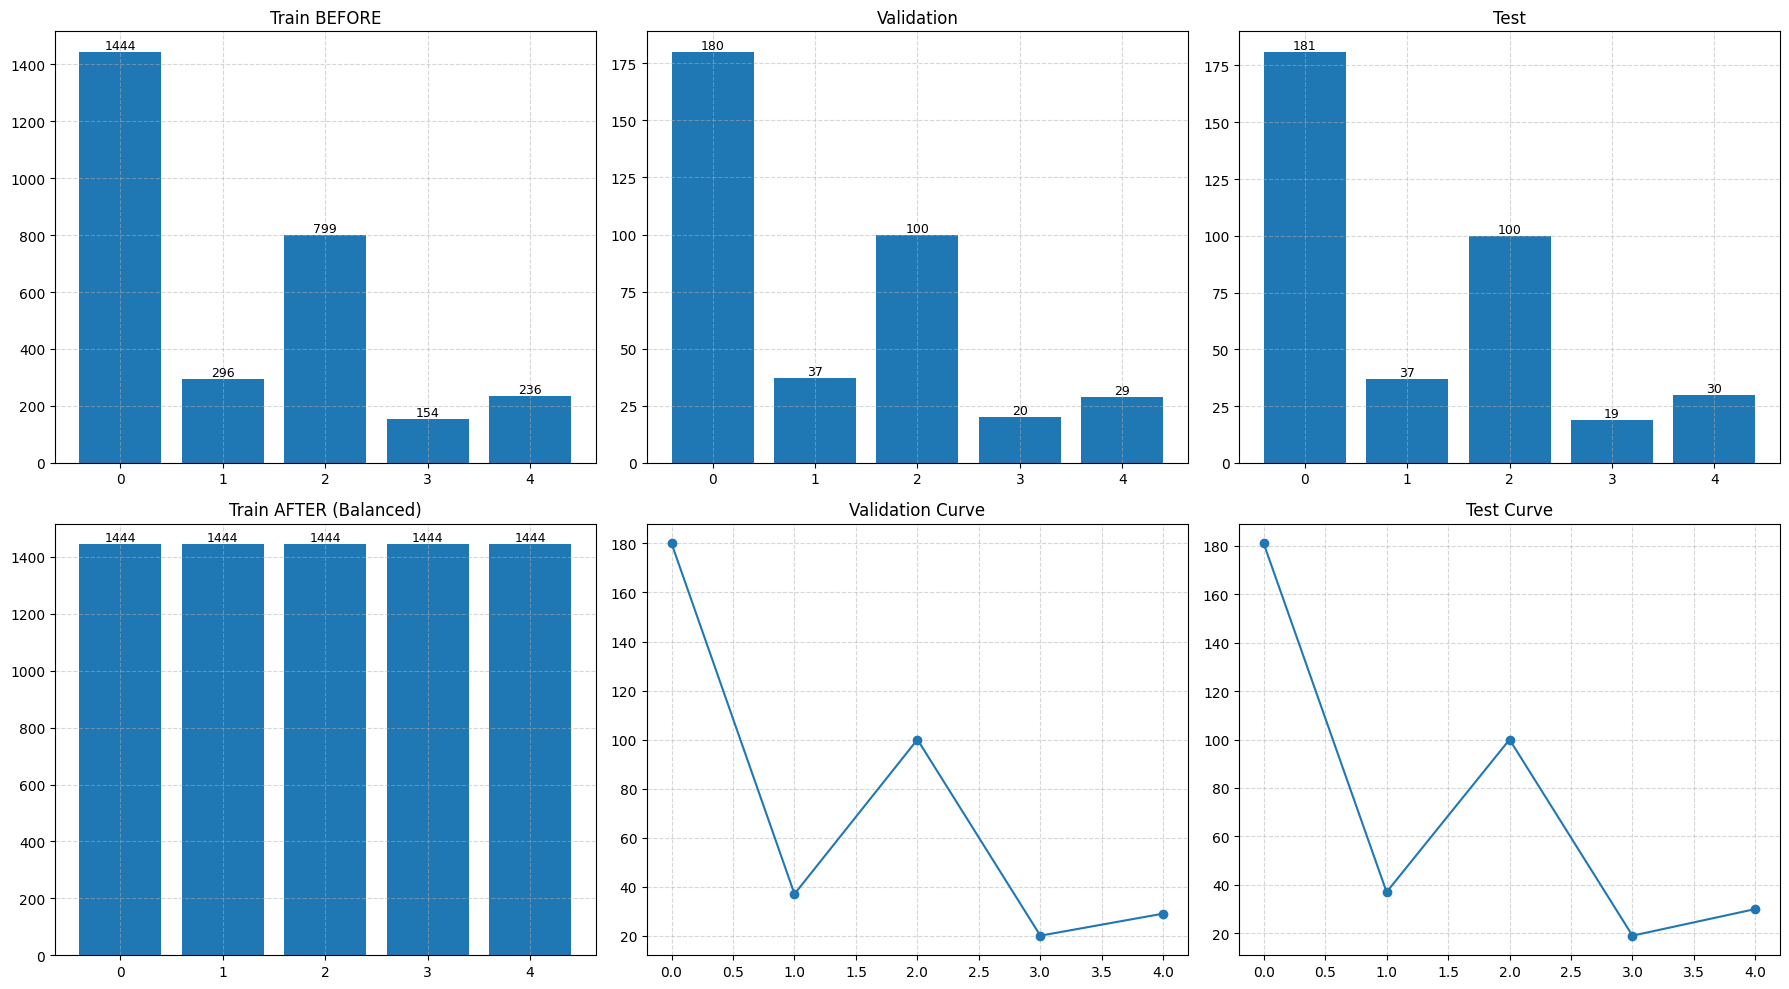


 Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/before_after_balancing.png


In [10]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =========================
# FUNCTION: ADD LABELS
# =========================
def add_labels(ax, counts):
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, str(v), ha='center', va='bottom', fontsize=9)

# =========================
# STEP 1 — SPLIT DATA
# =========================
train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.2,
    stratify=aptos_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# =========================
# STEP 2 — BEFORE BALANCING
# =========================
print("===== BEFORE BALANCING =====")

train_counts_before = train_df["label"].value_counts().sort_index()
val_counts = val_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

print("\nTrain (Original):\n", train_counts_before)
print("\nValidation:\n", val_counts)
print("\nTest:\n", test_counts)

# =========================
# STEP 3 — BALANCE TRAIN SET
# =========================
max_count = train_counts_before.max()

balanced_train_df = train_df.groupby("label").apply(
    lambda x: x.sample(max_count, replace=True)
).reset_index(drop=True)

train_counts_after = balanced_train_df["label"].value_counts().sort_index()

print("\n===== AFTER BALANCING =====")
print("\nTrain (Balanced):\n", train_counts_after)

# =========================
# STEP 4 — PLOT
# =========================
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# ===== ROW 1 → BEFORE =====
axes[0,0].bar(train_counts_before.index, train_counts_before.values)
add_labels(axes[0,0], train_counts_before)
axes[0,0].set_title("Train BEFORE")

axes[0,1].bar(val_counts.index, val_counts.values)
add_labels(axes[0,1], val_counts)
axes[0,1].set_title("Validation")

axes[0,2].bar(test_counts.index, test_counts.values)
add_labels(axes[0,2], test_counts)
axes[0,2].set_title("Test")

# ===== ROW 2 → AFTER =====
axes[1,0].bar(train_counts_after.index, train_counts_after.values)
add_labels(axes[1,0], train_counts_after)
axes[1,0].set_title("Train AFTER (Balanced)")

axes[1,1].plot(val_counts.index, val_counts.values, marker='o')
axes[1,1].set_title("Validation Curve")

axes[1,2].plot(test_counts.index, test_counts.values, marker='o')
axes[1,2].set_title("Test Curve")

for ax in axes.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# =========================
# STEP 5 — SAVE
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
os.makedirs(SAVE_PATH, exist_ok=True)

save_file = os.path.join(SAVE_PATH, "before_after_balancing.png")
plt.savefig(save_file, dpi=300)
plt.show()

print(f"\n Saved at: {save_file}")

# =========================
# STEP 6 — FINAL OUTPUT FOR TRAINING
# =========================

#  USE THIS FOR TRAINING
final_train_df = balanced_train_df
final_val_df = val_df
final_test_df = test_df

**Balanced Dataset Visualization**


===== OVERLAP CHECK =====
Train-Val: 0
Train-Test: 0
Val-Test: 0

===== TRAIN BALANCED =====
label
0    1444
1    1444
2    1444
3    1444
4    1444
Name: count, dtype: int64

===== VALIDATION BALANCED =====
label
0    180
1    180
2    180
3    180
4    180
Name: count, dtype: int64

===== TEST BALANCED =====
label
0    181
1    181
2    181
3    181
4    181
Name: count, dtype: int64


/tmp/ipykernel_1323/507508288.py:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(
/tmp/ipykernel_1323/507508288.py:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(
/tmp/ipykernel_1323/507508288.py:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the op

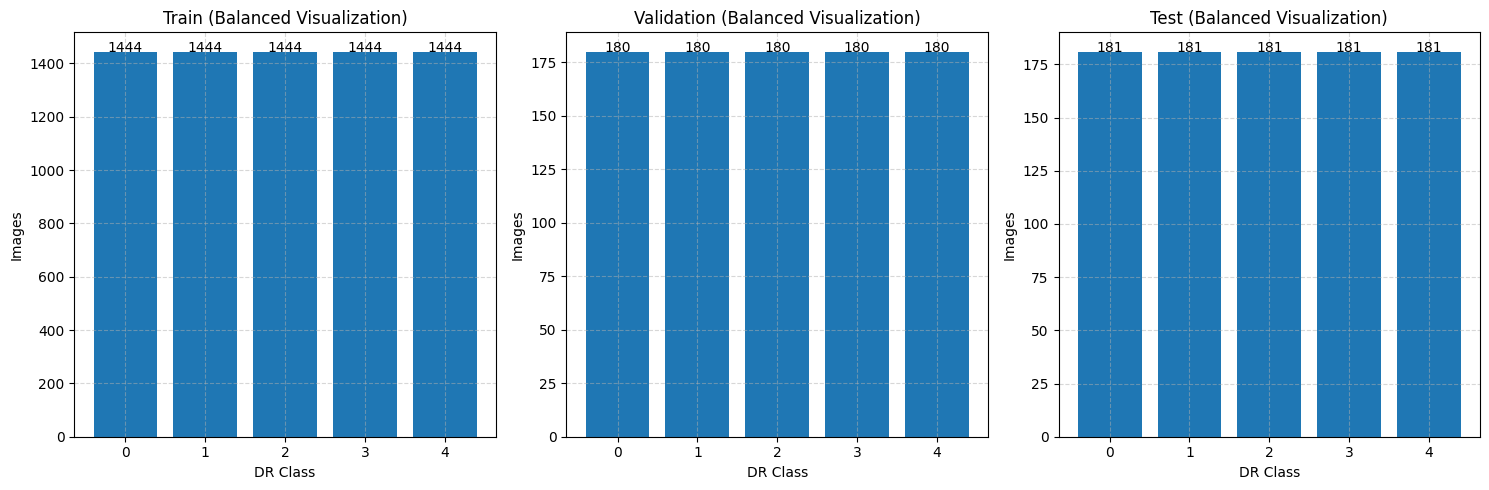


 Saved at:
/content/drive/MyDrive/DR_New_Results/APTOS/balanced_visualization.png


In [11]:
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# =========================
# SAVE PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# =========================
# SPLIT (80/10/10)
# =========================
train_df, temp_df = train_test_split(

    aptos_df,

    test_size=0.2,

    stratify=aptos_df["label"],

    random_state=42
)

val_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=42
)

# =========================
# OVERLAP CHECK
# =========================
train_set = set(
    train_df["image_path"]
)

val_set = set(
    val_df["image_path"]
)

test_set = set(
    test_df["image_path"]
)

print("\n===== OVERLAP CHECK =====")

print(
    "Train-Val:",
    len(train_set & val_set)
)

print(
    "Train-Test:",
    len(train_set & test_set)
)

print(
    "Val-Test:",
    len(val_set & test_set)
)

# =========================
# BALANCE FUNCTION
# (ONLY FOR VISUALIZATION)
# =========================
def balance_df(df):

    max_count = df[
        "label"
    ].value_counts().max()

    balanced_df = df.groupby(
        "label",
        group_keys=False
    ).apply(

        lambda x: x.sample(
            max_count,
            replace=True,
            random_state=42
        )
    )

    return balanced_df.reset_index(
        drop=True
    )

# =========================
# BALANCED COPIES
# (VISUALIZATION ONLY)
# =========================
train_vis = balance_df(
    train_df
)

val_vis = balance_df(
    val_df
)

test_vis = balance_df(
    test_df
)

# =========================
# COUNTS
# =========================
train_counts = train_vis[
    "label"
].value_counts().sort_index()

val_counts = val_vis[
    "label"
].value_counts().sort_index()

test_counts = test_vis[
    "label"
].value_counts().sort_index()

# =========================
# PRINT COUNTS
# =========================
print("\n===== TRAIN BALANCED =====")

print(train_counts)

print("\n===== VALIDATION BALANCED =====")

print(val_counts)

print("\n===== TEST BALANCED =====")

print(test_counts)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

# =========================
# FUNCTION
# =========================
def add_labels(ax, counts):

    for i, v in enumerate(
        counts.values
    ):

        ax.text(
            counts.index[i],
            v,
            str(v),
            ha='center'
        )

# =========================
# TRAIN
# =========================
axes[0].bar(

    train_counts.index,

    train_counts.values
)

add_labels(
    axes[0],
    train_counts
)

axes[0].set_title(
    "Train (Balanced Visualization)"
)

# =========================
# VALIDATION
# =========================
axes[1].bar(

    val_counts.index,

    val_counts.values
)

add_labels(
    axes[1],
    val_counts
)

axes[1].set_title(
    "Validation (Balanced Visualization)"
)

# =========================
# TEST
# =========================
axes[2].bar(

    test_counts.index,

    test_counts.values
)

add_labels(
    axes[2],
    test_counts
)

axes[2].set_title(
    "Test (Balanced Visualization)"
)

# =========================
# COMMON SETTINGS
# =========================
for ax in axes:

    ax.set_xlabel(
        "DR Class"
    )

    ax.set_ylabel(
        "Images"
    )

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

plt.tight_layout()

# =========================
# SAVE
# =========================
save_file = os.path.join(

    SAVE_PATH,

    "balanced_visualization.png"
)

plt.savefig(
    save_file,
    dpi=300
)

plt.show()

# =========================
# FINAL MESSAGE
# =========================
print(
    f"\n Saved at:\n{save_file}"
)

**Image Path Mapping and Dataset Validation**

In [12]:
# =========================
# MAP IMAGE PATHS
# =========================
for df in [train_df, val_df, test_df]:

    df["image_path"] = df[
        "id_code"
    ].map(image_dict)

# =========================
# CHECK MISSING IMAGES
# =========================
print(
    "Missing images (Train):",
    train_df["image_path"].isna().sum()
)

print(
    "Missing images (Val):",
    val_df["image_path"].isna().sum()
)

print(
    "Missing images (Test):",
    test_df["image_path"].isna().sum()
)

# =========================
# CLEAN DATAFRAMES
# =========================
cleaned_dfs = []

for df in [train_df, val_df, test_df]:

    # Remove missing paths
    df = df.dropna(
        subset=["image_path"]
    )

    # Keep existing files only
    df = df[
        df["image_path"].apply(
            os.path.exists
        )
    ]

    # Fix label type
    df["label"] = df[
        "label"
    ].astype(int)

    # Reset index
    df = df.reset_index(
        drop=True
    )

    cleaned_dfs.append(df)

# =========================
# FINAL DATAFRAMES
# =========================
train_df, val_df, test_df = cleaned_dfs

# =========================
# FINAL COUNTS
# =========================
print(
    f"\nTrain: {len(train_df)}"
)

print(
    f"Val: {len(val_df)}"
)

print(
    f"Test: {len(test_df)}"
)

Missing images (Train): 0
Missing images (Val): 0
Missing images (Test): 0

Train: 2929
Val: 366
Test: 367


**Train Set Balancing**

In [13]:
from sklearn.model_selection import train_test_split

# =========================
# STEP 1: SPLIT DATASET
# =========================
train_df, temp_df = train_test_split(

    aptos_df,

    test_size=0.2,

    stratify=aptos_df["label"],

    random_state=42
)

val_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=42
)

# =========================
# SHOW DISTRIBUTION
# =========================
print("\n===== TRAIN DISTRIBUTION =====")

print(
    train_df["label"].value_counts()
)

print("\n===== VALIDATION DISTRIBUTION =====")

print(
    val_df["label"].value_counts()
)

print("\n===== TEST DISTRIBUTION =====")

print(
    test_df["label"].value_counts()
)

# =========================
# TRANSFORMS
# =========================
IMG_SIZE = 380

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(5),

    transforms.RandomAffine(
        degrees=0,
        scale=(0.98, 1.02)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])


===== TRAIN DISTRIBUTION =====
label
0    1444
2     799
1     296
4     236
3     154
Name: count, dtype: int64

===== VALIDATION DISTRIBUTION =====
label
0    180
2    100
1     37
4     29
3     20
Name: count, dtype: int64

===== TEST DISTRIBUTION =====
label
0    181
2    100
1     37
4     30
3     19
Name: count, dtype: int64


**Training Data Preprocessing and Augmentation**

In [14]:
# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================
# IMAGE SIZE
# =========================
IMG_SIZE = 380 if device.type == "cuda" else 224

print(
    f"Using {device} | IMG_SIZE={IMG_SIZE}"
)

# =========================
# TRAIN TRANSFORM
# =========================
train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    # Mild augmentation
    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(5),

    transforms.RandomAffine(
        degrees=0,
        scale=(0.98, 1.02)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# VALIDATION / TEST
# =========================
val_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

Using cuda | IMG_SIZE=380


**Dataset and DataLoader Preparation**

In [15]:
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from PIL import Image, ImageFile

import torch
import os

# =========================
# FIX CORRUPTED IMAGES
# =========================
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================
# DATASET CLASS
# =========================
class APTOSDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(
            drop=True
        )

        self.transform = transform

        self.valid_indices = []

        for i in range(len(self.df)):

            path = self.df.loc[
                i,
                "image_path"
            ]

            if (
                isinstance(path, str)
                and os.path.exists(path)
            ):

                self.valid_indices.append(i)

        print(
            f"Valid images: {len(self.valid_indices)}"
        )

    def __len__(self):

        return len(self.valid_indices)

    def __getitem__(self, idx):

        real_idx = self.valid_indices[idx]

        row = self.df.loc[real_idx]

        img_path = row["image_path"]

        label = int(row["label"])

        try:

            image = Image.open(
                img_path
            ).convert("RGB")

        except Exception:

            image = Image.new(
                "RGB",
                (IMG_SIZE, IMG_SIZE)
            )

        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

# =========================
# CREATE DATASETS
# =========================
train_dataset = APTOSDataset(
    train_df,
    transform=train_transform
)

val_dataset = APTOSDataset(
    val_df,
    transform=val_transform
)

test_dataset = APTOSDataset(
    test_df,
    transform=val_transform
)

print(
    f"\nTrain: {len(train_dataset)}"
)

print(
    f"Val: {len(val_dataset)}"
)

print(
    f"Test: {len(test_dataset)}"
)

# =========================
# SAFE DATALOADER SETTINGS
# =========================
batch_size = 16

num_workers = 0

pin_memory = False

# =========================
# WEIGHTED SAMPLER
# =========================
labels = train_dataset.df[
    "label"
].values

labels_tensor = torch.tensor(
    labels,
    dtype=torch.long
)

class_counts = torch.bincount(
    labels_tensor
)

weights = 1.0 / (
    class_counts.float() + 1e-6
)

sample_weights = weights[
    labels_tensor
]

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(
        sample_weights
    ),

    replacement=True
)

# =========================
# TRAIN LOADER
# =========================
train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    sampler=sampler,

    num_workers=num_workers,

    pin_memory=pin_memory,

    drop_last=True
)

# =========================
# VALIDATION LOADER
# =========================
val_loader = DataLoader(

    val_dataset,

    batch_size=batch_size,

    shuffle=False,

    num_workers=num_workers,

    pin_memory=pin_memory
)

# =========================
# TEST LOADER
# =========================
test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    shuffle=False,

    num_workers=num_workers,

    pin_memory=pin_memory
)

print("\nDataLoaders created successfully")

Valid images: 2929
Valid images: 366
Valid images: 367

Train: 2929
Val: 366
Test: 367

DataLoaders created successfully


**DataLoader**

**MODEL ARCHITECTURE**

In [16]:
import torch
import torch.nn as nn

from torchvision.models import (
    densenet201,
    DenseNet201_Weights
)

# =========================
# CROSS PATCH ATTENTION
# =========================
class CrossPatchAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = max(
            in_channels // 8,
            1
        )

        self.query = nn.Conv2d(
            in_channels,
            reduced_channels,
            kernel_size=1
        )

        self.key = nn.Conv2d(
            in_channels,
            reduced_channels,
            kernel_size=1
        )

        self.value = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=1
        )

        self.gamma = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        q = self.query(x).flatten(2)

        k = self.key(x).flatten(2)

        v = self.value(x).flatten(2)

        attn = torch.bmm(

            q.transpose(1, 2),

            k

        ) / (q.shape[1] ** 0.5)

        attn = torch.softmax(
            attn,
            dim=-1
        )

        out = torch.bmm(
            v,
            attn.transpose(1, 2)
        )

        out = out.view(
            B, C, H, W
        )

        return (
            self.gamma * out + x
        )

# =========================
# REGION ATTENTION
# =========================
class RegionAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = max(
            in_channels // 4,
            1
        )

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                reduced_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                reduced_channels,
                in_channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        attention_map = self.conv(x)

        return x * attention_map

# =========================
# FINAL DR MODEL
# =========================
class DRModel(nn.Module):

    def __init__(self, num_classes=5, use_cross=True, use_region=True):

        super().__init__()

        backbone = densenet201(

            weights=DenseNet201_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        in_channels = 1920

        # Freeze shallow layers
        for param in list(
            self.features.parameters()
        )[:50]:

            param.requires_grad = False

        # Feature enhancement
        self.norm = nn.BatchNorm2d(
            in_channels
        )

        self.use_cross = use_cross
        if self.use_cross:
            self.cross_attention = CrossPatchAttention(
                in_channels
            )

        self.use_region = use_region
        if self.use_region:
            self.region_attention = RegionAttention(
                in_channels
            )

        self.feat_dropout = nn.Dropout2d(
            0.20
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classification head
        self.classifier = nn.Sequential(

            nn.BatchNorm1d(
                in_channels
            ),

            nn.Linear(
                in_channels,
                512
            ),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                256
            ),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        # DenseNet activation
        x = torch.relu(x)

        x = self.norm(x)

        if self.use_cross:
            x = self.cross_attention(x)

        if self.use_region:
            x = self.region_attention(x)

        x = self.feat_dropout(x)

        x = self.pool(x)

        x = torch.flatten(
            x,
            1
        )

        return self.classifier(x)


**CONNECT MODEL TO TRAINING**

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 102MB/s]



Starting fresh training


Epoch 1/15: 100%|██████████| 183/183 [20:11<00:00,  6.62s/it, loss=1.34]



Epoch 1
Train Loss: 1.4245
QWK: 0.7537
Best model saved
Checkpoint saved for Epoch 1


...


Epoch 13
Train Loss: 0.3662
QWK: 0.8524
Checkpoint saved for Epoch 13


Epoch 14/15: 100%|██████████| 183/183 [11:35<00:00,  3.80s/it, loss=0.297]



Epoch 14
Train Loss: 0.3626
QWK: 0.8475
Checkpoint saved for Epoch 14


Epoch 15/15: 100%|██████████| 183/183 [11:19<00:00,  3.71s/it, loss=0.293]



Epoch 15
Train Loss: 0.3382
QWK: 0.8555
Checkpoint saved for Epoch 15

Final Best QWK: 0.8562

Best model reloaded


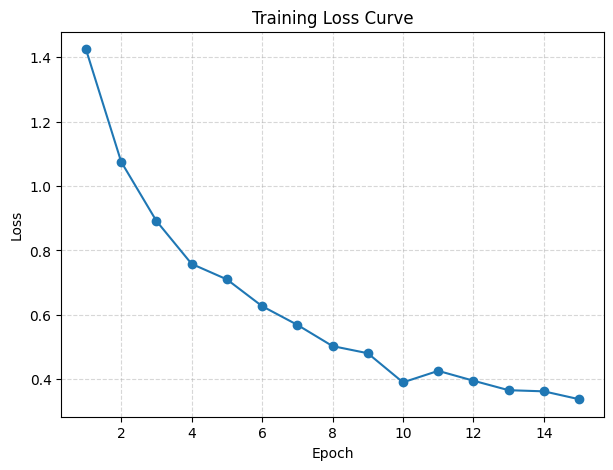

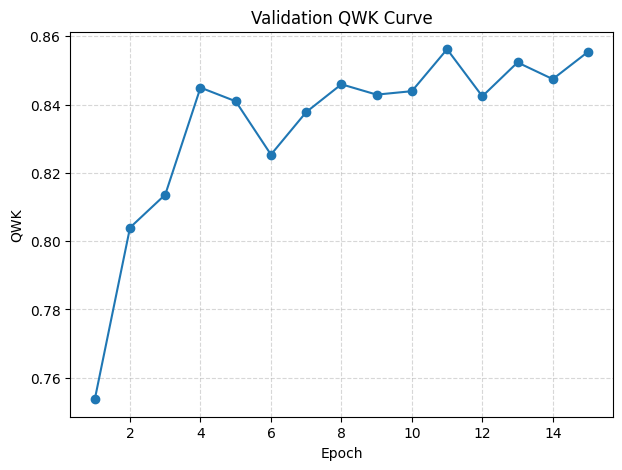

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score

# =========================
# SAVE PATHS
# =========================
SAVE_DIR = "/content/drive/MyDrive/DR_DenseNet201"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_model.pth"
)

CHECKPOINT_PATH = os.path.join(
    SAVE_DIR,
    "last_checkpoint.pth"
)

# =========================
# MODEL
# =========================
model = DRModel(
    num_classes=5
).to(device)

# =========================
# LOSS FUNCTION
# =========================
criterion = nn.CrossEntropyLoss()

# =========================
# OPTIMIZER
# =========================
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

# =========================
# TRAINING SETTINGS
# =========================
num_epochs = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

# =========================
# RESUME TRAINING
# =========================
start_epoch = 0

best_qwk = 0

train_losses = []

qwk_scores = []

if os.path.isfile(CHECKPOINT_PATH):

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    start_epoch = checkpoint['epoch'] + 1

    best_qwk = checkpoint['best_qwk']

    train_losses = checkpoint.get(
        'train_losses',
        []
    )

    qwk_scores = checkpoint.get(
        'qwk_scores',
        []
    )

    print(
        f"Resumed From Epoch {start_epoch}"
    )

    print(
        f"Previous Best QWK: {best_qwk:.4f}"
    )

else:

    print(
        "\nStarting fresh training"
    )

# =========================
# TRAIN LOOP
# =========================
for epoch in range(
    start_epoch,
    num_epochs
):

    model.train()

    train_loss = 0

    loop = tqdm(

        train_loader,

        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for images, labels in loop:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    qwk = cohen_kappa_score(

        all_labels,

        all_preds,

        weights='quadratic'
    )

    scheduler.step()

    # =========================
    # AVERAGE LOSS
    # =========================
    avg_train_loss = (
        train_loss / len(train_loader)
    )

    train_losses.append(
        avg_train_loss
    )

    qwk_scores.append(
        qwk
    )

    print(f"\nEpoch {epoch+1}")

    print(
        f"Train Loss: {avg_train_loss:.4f}"
    )

    print(
        f"QWK: {qwk:.4f}"
    )

    # =========================
    # SAVE BEST MODEL
    # =========================
    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            "Best model saved"
        )

    # =========================
    # SAVE CHECKPOINT
    # =========================
    checkpoint = {

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'scheduler_state_dict': scheduler.state_dict(),

        'best_qwk': best_qwk,

        'train_losses': train_losses,

        'qwk_scores': qwk_scores
    }

    torch.save(
        checkpoint,
        CHECKPOINT_PATH
    )

    print(
        f"Checkpoint saved for Epoch {epoch+1}"
    )

# =========================
# FINAL RESULT
# =========================
print(
    "\nFinal Best QWK:",
    round(best_qwk, 4)
)

# =========================
# LOAD BEST MODEL
# =========================
if os.path.exists(BEST_MODEL_PATH):

    model.load_state_dict(

        torch.load(
            BEST_MODEL_PATH,
            map_location=device
        )
    )

    model.eval()

    print(
        "\nBest model reloaded"
    )

# =========================
# TRAINING CURVES
# =========================
epochs_range = range(
    1,
    len(train_losses) + 1
)

# =========================
# LOSS CURVE
# =========================
plt.figure(figsize=(7,5))

plt.plot(
    epochs_range,
    train_losses,
    marker='o'
)

plt.title(
    "Training Loss Curve"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.show()

# =========================
# QWK CURVE
# =========================
plt.figure(figsize=(7,5))

plt.plot(
    epochs_range,
    qwk_scores,
    marker='o'
)

plt.title(
    "Validation QWK Curve"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "QWK"
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.show()

**Test Sample Count**

In [ ]:
print("Total test samples:", len(test_loader.dataset))

Total test samples: 367


**Test Class Distribution**

In [ ]:
y_true_check = []

for _, labels in test_loader:
    y_true_check.extend(labels.numpy())

print("Counts from loader:", np.bincount(y_true_check))

Counts from loader: [181  37 100  19  30]


**Final Evaluation**


Best model loaded

Original Counts: [181  37 100  19  30]

Predicted Counts: [180  46  93  23  25]

EVALUATION METRICS
Accuracy  : 0.8256
Precision : 0.8331
Recall    : 0.8256
F1-Score  : 0.8277
QWK Score : 0.9065

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9833    0.9779    0.9806       181
           1     0.6087    0.7568    0.6747        37
           2     0.8065    0.7500    0.7772       100
           3     0.3478    0.4211    0.3810        19
           4     0.6000    0.5000    0.5455        30

    accuracy                         0.8256       367
   macro avg     0.6693    0.6811    0.6718       367
weighted avg     0.8331    0.8256    0.8277       367


Balanced Counts: [181 181 181 181 181]


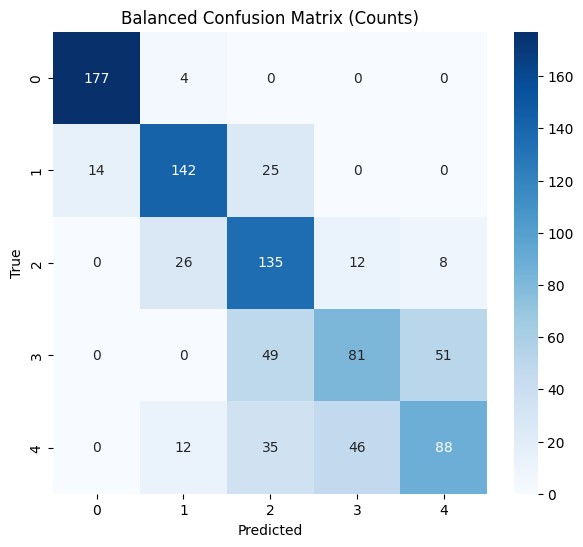

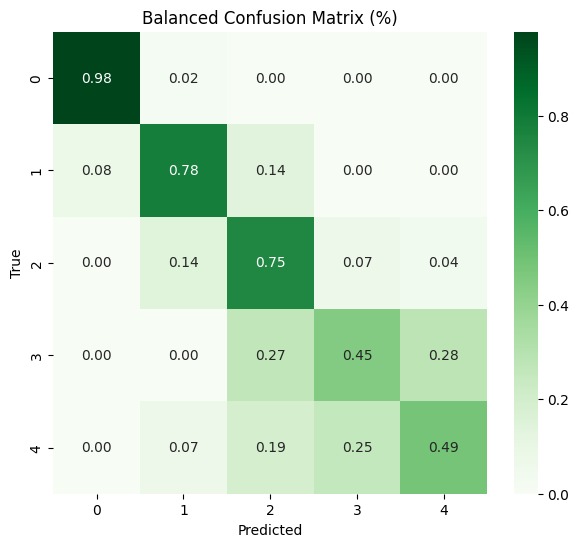

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# =========================
# LOAD BEST MODEL
# =========================
BEST_MODEL_PATH = "/content/drive/MyDrive/DR_DenseNet201/best_model.pth"

# Recreate model
model = DRModel(
    num_classes=5
).to(device)

# Load weights
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

print("\nBest model loaded")

# =========================
# GET TEST PREDICTIONS
# =========================
y_true = []

y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

# =========================
# NUMPY ARRAYS
# =========================
y_true = np.array(y_true)

y_pred = np.array(y_pred)

# =========================
# ORIGINAL COUNTS
# =========================
print(
    "\nOriginal Counts:",
    np.bincount(y_true)
)

print(
    "\nPredicted Counts:",
    np.bincount(y_pred)
)

# =========================
# REAL EVALUATION METRICS
# =========================
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

# =========================
# PRINT METRICS
# =========================
print("\n========================")
print("EVALUATION METRICS")
print("========================")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1-Score  : {f1:.4f}")

print(f"QWK Score : {qwk:.4f}")

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n========================")
print("CLASSIFICATION REPORT")
print("========================")

print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )
)

# =========================
# BALANCED MATRIX ONLY
# =========================
class_counts = np.bincount(y_true)

max_count = class_counts.max()

balanced_indices = []

for cls in range(len(class_counts)):

    cls_idx = np.where(
        y_true == cls
    )[0]

    if len(cls_idx) < max_count:

        extra_idx = np.random.choice(

            cls_idx,

            max_count - len(cls_idx),

            replace=True
        )

        cls_idx = np.concatenate([

            cls_idx,

            extra_idx
        ])

    balanced_indices.extend(cls_idx)

balanced_indices = np.array(
    balanced_indices
)

# =========================
# BALANCED LABELS
# =========================
y_true_bal = y_true[
    balanced_indices
]

y_pred_bal = y_pred[
    balanced_indices
]

print(
    "\nBalanced Counts:",
    np.bincount(y_true_bal)
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    y_true_bal,
    y_pred_bal
)

# =========================
# NORMALIZED MATRIX
# =========================
cm_norm = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

labels = ["0", "1", "2", "3", "4"]

# =========================
# PLOT FUNCTION
# =========================
def plot_cm(matrix, title, fmt, cmap):

    plt.figure(figsize=(7,6))

    sns.heatmap(

        matrix,

        annot=True,

        fmt=fmt,

        cmap=cmap,

        xticklabels=labels,

        yticklabels=labels
    )

    plt.title(title)

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

# =========================
# COUNTS MATRIX
# =========================
plot_cm(
    cm,
    "Balanced Confusion Matrix (Counts)",
    'd',
    "Blues"
)

# =========================
# PERCENT MATRIX
# =========================
plot_cm(
    cm_norm,
    "Balanced Confusion Matrix (%)",
    ".2f",
    "Greens"
)

In [ ]:
# =========================
# SAVE CONFUSION MATRICES
# =========================

import os

# =========================
# SAVE PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

labels = ["0", "1", "2", "3", "4"]

# =========================
# COMMON SAVE FUNCTION
# =========================
def save_cm(matrix, title, fmt, cmap, filename):

    plt.figure(figsize=(6,5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    save_path = os.path.join(
        SAVE_PATH,
        filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    print(f"Saved at: {save_path}")

# =========================
# SAVE MATRICES
# =========================
save_cm(
    cm,
    "Confusion Matrix (Counts)",
    'd',
    "Blues",
    "confusion_matrix_counts.png"
)

save_cm(
    cm_norm,
    "Confusion Matrix (Percentage)",
    ".2f",
    "Greens",
    "confusion_matrix_percentage.png"
)

Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/confusion_matrix_counts.png
Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/confusion_matrix_percentage.png


**Ablation Study **

In [17]:
# ==========================================
# FULL FINAL ABLATION STUDY CODE
# GPU + CHECKPOINT RESUME + FAST TRAINING
# DenseNet201 Backbone
# ==========================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    f1_score
)

from torch.amp import (
    autocast,
    GradScaler
)

# ==========================================
# DEVICE
# ==========================================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

# ==========================================
# SAVE PATH
# ==========================================
SAVE_PATH = (
    "/content/drive/MyDrive/"
    "APTOS/"
    "ablation_study"
)

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# ==========================================
# TRAIN MODEL FUNCTION
# ==========================================
def train_model(

    cfg,

    experiment_name,

    epochs=10
):

    # ======================================
    # MODEL
    # ======================================
    model = DRModel(

        num_classes=5,

        use_cross=cfg['use_cross'],

        use_region=cfg['use_region']

    ).to(device)

    # ======================================
    # LOSS FUNCTION
    # ======================================
    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    # ======================================
    # OPTIMIZER
    # ======================================
    optimizer = optim.AdamW(

        model.parameters(),

        lr=1e-4,

        weight_decay=1e-4
    )

    # ======================================
    # MIXED PRECISION
    # ======================================
    scaler = GradScaler()

    # ======================================
    # SCHEDULER
    # ======================================
    scheduler = optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=epochs
    )

    # ======================================
    # CHECKPOINT PATH
    # ======================================
    checkpoint_path = os.path.join(

        SAVE_PATH,

        f"{experiment_name}.pth"
    )

    # ======================================
    # INITIAL VALUES
    # ======================================
    start_epoch = 0

    best_qwk = -1.0

    best_acc = 0.0

    best_f1 = 0.0

    # ======================================
    # RESUME CHECKPOINT
    # ======================================
    if os.path.exists(checkpoint_path):

        try:

            print(f"\nResuming {experiment_name}...")

            checkpoint = torch.load(

                checkpoint_path,

                map_location=device,

                weights_only=False
            )

            # ==============================
            # LOAD STATES
            # ==============================
            model.load_state_dict(
                checkpoint["model"],
                strict=False
            )

            optimizer.load_state_dict(
                checkpoint["optimizer"]
            )

            scheduler.load_state_dict(
                checkpoint["scheduler"]
            )

            start_epoch = (
                checkpoint["epoch"] + 1
            )

            best_qwk = checkpoint["best_qwk"]

            best_acc = checkpoint["best_acc"]

            best_f1 = checkpoint["best_f1"]

            print(
                "Checkpoint loaded successfully"
            )

            print(
                f"Starting from Epoch {start_epoch+1}"
            )

            # ==============================
            # SKIP COMPLETED
            # ==============================
            if start_epoch >= epochs:

                print(
                    f"{experiment_name} already completed."
                )

                return (
                    best_acc,
                    best_f1,
                    best_qwk
                )

        except Exception as e:

            print(
                f"Checkpoint loading failed: {e}"
            )

            print(
                "Starting fresh training..."
            )

    else:

        print(
            f"\nStarting fresh training for {experiment_name}"
        )

    # ======================================
    # TRAINING LOOP
    # ======================================
    for epoch in range(start_epoch, epochs):

        model.train()

        train_loss = 0

        loop = tqdm(

            train_loader,

            desc=f"{experiment_name} Epoch {epoch+1}/{epochs}"
        )

        for images, labels in loop:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            # ==================================
            # MIXED PRECISION
            # ==================================
            with autocast(
                device_type=device.type
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

            train_loss += loss.item()

            loop.set_postfix(
                loss=loss.item()
            )

        # ======================================
        # VALIDATION
        # ======================================
        model.eval()

        all_preds = []

        all_labels = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                preds = torch.argmax(
                    outputs,
                    dim=1
                )

                all_preds.extend(
                    preds.cpu().numpy()
                )

                all_labels.extend(
                    labels.numpy()
                )

        # ======================================
        # METRICS
        # ======================================
        current_qwk = cohen_kappa_score(

            all_labels,

            all_preds,

            weights='quadratic'
        )

        current_acc = accuracy_score(

            all_labels,

            all_preds
        )

        current_f1 = f1_score(

            all_labels,

            all_preds,

            average='weighted',

            zero_division=0
        )

        scheduler.step()

        avg_loss = (
            train_loss / len(train_loader)
        )

        # ======================================
        # PRINT RESULTS
        # ======================================
        print(

            f"\nEpoch {epoch+1}/{epochs}"

            f"\nLoss: {avg_loss:.4f}"

            f"\nAccuracy: {current_acc:.4f}"

            f"\nF1: {current_f1:.4f}"

            f"\nQWK: {current_qwk:.4f}"
        )

        # ======================================
        # SAVE BEST
        # ======================================
        if current_qwk > best_qwk:

            best_qwk = current_qwk

            best_acc = current_acc

            best_f1 = current_f1

            print("Best model updated")

        # ======================================
        # SAVE CHECKPOINT
        # ======================================
        torch.save({

            "epoch": epoch,

            "model": model.state_dict(),

            "optimizer": optimizer.state_dict(),

            "scheduler": scheduler.state_dict(),

            "best_qwk": best_qwk,

            "best_acc": best_acc,

            "best_f1": best_f1

        }, checkpoint_path)

        print(
            "Checkpoint saved"
        )

    print(

        f"\n--- {experiment_name} Completed ---"

        f"\nBest Accuracy: {best_acc:.4f}"

        f"\nBest F1: {best_f1:.4f}"

        f"\nBest QWK: {best_qwk:.4f}"
    )

    return best_acc, best_f1, best_qwk

# ==========================================
# ABLATION CONFIGURATIONS
# ==========================================
experiments = {

    # ======================================
    # 1. BASELINE
    # ======================================
    "Baseline": {

        "use_cross": False,

        "use_region": False
    },

    # ======================================
    # 2. CROSS PATCH ONLY
    # ======================================
    "Baseline + CrossPatch": {

        "use_cross": True,

        "use_region": False
    },

    # ======================================
    # 3. REGION ATTENTION ONLY
    # ======================================
    "Baseline + RegionAttention": {

        "use_cross": False,

        "use_region": True
    },

    # ======================================
    # 4. FINAL MODEL
    # ======================================
    "Baseline + CrossPatch + Region": {

        "use_cross": True,

        "use_region": True
    }
}

# ==========================================
# RUN ABLATION STUDY
# ==========================================
results = []

for name, cfg in experiments.items():

    print("\nRunning:", name)

    acc, f1, qwk = train_model(

        cfg,

        name,

        epochs=10
    )

    results.append({

        "Model": name,

        "Accuracy": round(acc, 4),

        "F1": round(f1, 4),

        "QWK": round(qwk, 4)
    })

# ==========================================
# RESULTS TABLE
# ==========================================
df_results = pd.DataFrame(results)

print("\nFINAL RESULTS:\n")

print(df_results)

# ==========================================
# SAVE CSV
# ==========================================
csv_path = os.path.join(

    SAVE_PATH,

    "ablation_results.csv"
)

df_results.to_csv(

    csv_path,

    index=False
)

# ==========================================
# SAVE QWK PLOT
# ==========================================
plot_path = os.path.join(

    SAVE_PATH,

    "ablation_plot.png"
)

plt.figure(figsize=(7,4))

plt.bar(

    df_results["Model"],

    df_results["QWK"]
)

plt.ylabel("QWK")

plt.title(
    "DenseNet201 Ablation Study"
)

plt.grid(

    axis='y',

    linestyle='--',

    alpha=0.5
)

plt.xticks(rotation=10)

plt.savefig(

    plot_path,

    dpi=300,

    bbox_inches='tight'
)

plt.close()

print("\nSaved CSV:", csv_path)

print("Saved Plot:", plot_path)

Using: cuda

Running: Baseline
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 130MB/s]



Resuming Baseline...
Checkpoint loaded successfully
Starting from Epoch 11
Baseline already completed.

Running: Baseline + CrossPatch

Resuming Baseline + CrossPatch...
Checkpoint loaded successfully
Starting from Epoch 11
Baseline + CrossPatch already completed.

Running: Baseline + RegionAttention

Resuming Baseline + RegionAttention...
Checkpoint loaded successfully
Starting from Epoch 11
Baseline + RegionAttention already completed.

Running: Baseline + CrossPatch + Region

Resuming Baseline + CrossPatch + Region...
Checkpoint loaded successfully
Starting from Epoch 4


Baseline + CrossPatch + Region Epoch 4/10: 100%|██████████| 183/183 [15:10<00:00,  4.97s/it, loss=0.544]



Epoch 4/10
Loss: 0.6208
Accuracy: 0.7705
F1: 0.7793
QWK: 0.8290
Checkpoint saved


...


Epoch 8/10
Loss: 0.4709
Accuracy: 0.8087
F1: 0.8027
QWK: 0.8437
Checkpoint saved


Baseline + CrossPatch + Region Epoch 9/10: 100%|██████████| 183/183 [10:21<00:00,  3.40s/it, loss=0.568]



Epoch 9/10
Loss: 0.4639
Accuracy: 0.8142
F1: 0.8060
QWK: 0.8373
Checkpoint saved


Baseline + CrossPatch + Region Epoch 10/10: 100%|██████████| 183/183 [10:32<00:00,  3.45s/it, loss=0.413]



Epoch 10/10
Loss: 0.4514
Accuracy: 0.8169
F1: 0.8086
QWK: 0.8445
Checkpoint saved

--- Baseline + CrossPatch + Region Completed ---
Best Accuracy: 0.8142
Best F1: 0.8031
Best QWK: 0.8481

FINAL RESULTS:

                            Model  Accuracy      F1     QWK
0                        Baseline    0.7705  0.7770  0.8317
1           Baseline + CrossPatch    0.7678  0.7681  0.8328
2      Baseline + RegionAttention    0.8306  0.8290  0.8724
3  Baseline + CrossPatch + Region    0.8142  0.8031  0.8481

Saved CSV: /content/drive/MyDrive/APTOS/ablation_study/ablation_results.csv
Saved Plot: /content/drive/MyDrive/APTOS/ablation_study/ablation_plot.png
